In [ ]:
import zipfile
import os

zip_path = "/content/LearnDepth_Logistic_Regression_10_Problems_Datasets.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/logistic_regression_data")

print("ZIP extracted successfully!")

for root, dirs, files in os.walk("/content/logistic_regression_data"):
    for file in files:
        print(os.path.join(root, file))

ZIP extracted successfully!
/content/logistic_regression_data/LearnDepth_Logistic_Regression_10_Problems_Datasets.docx
/content/logistic_regression_data/datasets/dataset_06_equipment_failure_warning.csv
/content/logistic_regression_data/datasets/dataset_03_employee_attrition.csv
/content/logistic_regression_data/datasets/dataset_05_insurance_claim_flagging.csv
/content/logistic_regression_data/datasets/dataset_08_email_priority_classification.csv
/content/logistic_regression_data/datasets/dataset_09_delivery_delay_risk.csv
/content/logistic_regression_data/datasets/dataset_10_retail_return_risk.csv
/content/logistic_regression_data/datasets/dataset_01_customer_churn_risk.csv
/content/logistic_regression_data/datasets/dataset_04_ecommerce_purchase_intent.csv
/content/logistic_regression_data/datasets/dataset_02_loan_approval_screening.csv
/content/logistic_regression_data/datasets/dataset_07_student_placement_eligibility.csv


In [ ]:
import pandas as pd

file_path = "/content/logistic_regression_data/datasets/dataset_01_customer_churn_risk.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1000, 7)


,tenure_months,monthly_charges,support_tickets,avg_session_minutes,late_payments,contract_months,target
0,52,54.79,7,10.66,2,12,0
1,11,167.15,4,46.99,3,37,1
2,2,184.92,3,65.38,7,35,1
3,39,271.21,2,22.19,4,10,0
4,22,66.33,5,46.77,3,33,1


In [ ]:
print("Dataset Information")
print("-" * 50)

df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nTarget Distribution:")
print(df["target"].value_counts())

Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tenure_months        1000 non-null   int64  
 1   monthly_charges      1000 non-null   float64
 2   support_tickets      1000 non-null   int64  
 3   avg_session_minutes  1000 non-null   float64
 4   late_payments        1000 non-null   int64  
 5   contract_months      1000 non-null   int64  
 6   target               1000 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 54.8 KB

Missing Values:
tenure_months          0
monthly_charges        0
support_tickets        0
avg_session_minutes    0
late_payments          0
contract_months        0
target                 0
dtype: int64

Duplicate Rows: 0

Target Distribution:
target
0    500
1    500
Name: count, dtype: int64


In [ ]:
print("Statistical Summary")
print("-" * 50)

df.describe()


Statistical Summary
--------------------------------------------------


,tenure_months,monthly_charges,support_tickets,avg_session_minutes,late_payments,contract_months,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,30.121000,182.738270,3.129000,35.511450,3.081000,30.234000,0.50000
std,17.216526,144.743232,1.772428,19.954864,1.763959,17.254186,0.50025
min,1.000000,16.810000,0.000000,2.000000,0.000000,1.000000,0.00000
25%,15.000000,89.610000,2.000000,20.152500,2.000000,15.000000,0.00000
50%,30.000000,144.690000,3.000000,35.085000,3.000000,31.000000,0.50000
75%,45.000000,232.287500,4.000000,49.690000,4.000000,45.000000,1.00000
max,60.000000,1530.680000,11.000000,103.350000,10.000000,60.000000,1.00000


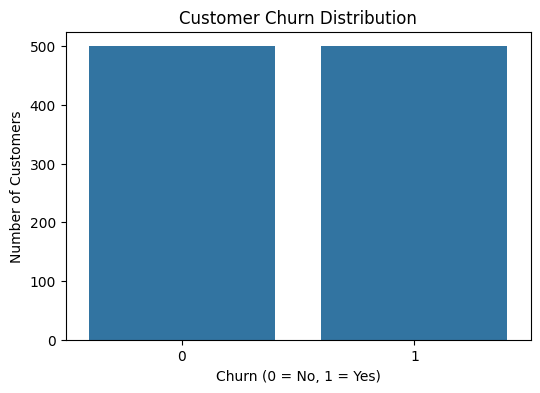

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

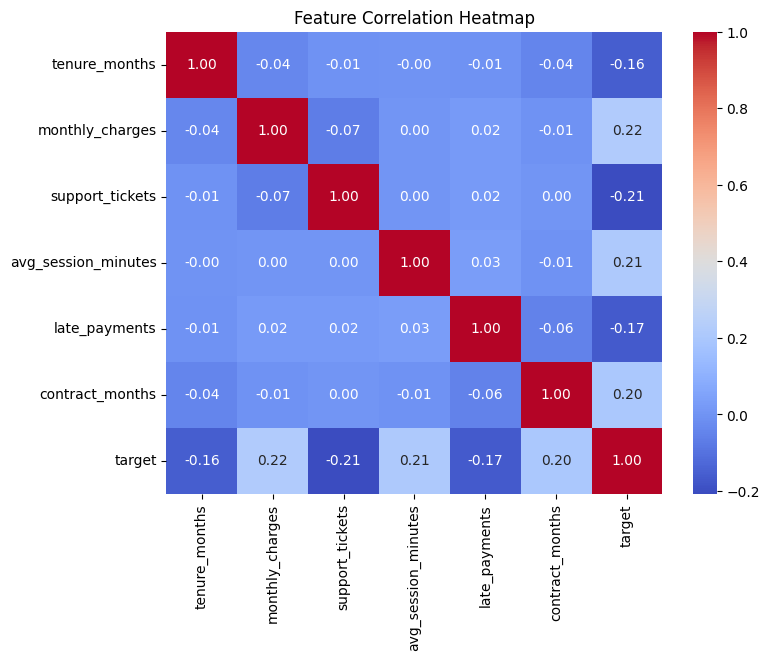

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['tenure_months', 'monthly_charges', 'support_tickets', 'avg_session_minutes', 'late_payments', 'contract_months']

Target:
target


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (800, 6)
Testing data shape: (200, 6)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
model = LogisticRegression(random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
# Make predictions on the test data
y_pred = model.predict(X_test_scaled)

# Get prediction probabilities
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully!")
print("First 10 predictions:", y_pred[:10])

Predictions generated successfully!
First 10 predictions: [1 1 0 0 1 1 0 1 1 0]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Model Evaluation Results")
print("-" * 40)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Model Evaluation Results
----------------------------------------
Accuracy  : 0.6800
Precision : 0.6837
Recall    : 0.6700
F1-Score  : 0.6768
ROC-AUC   : 0.7495


Confusion Matrix:
[[69 31]
 [33 67]]


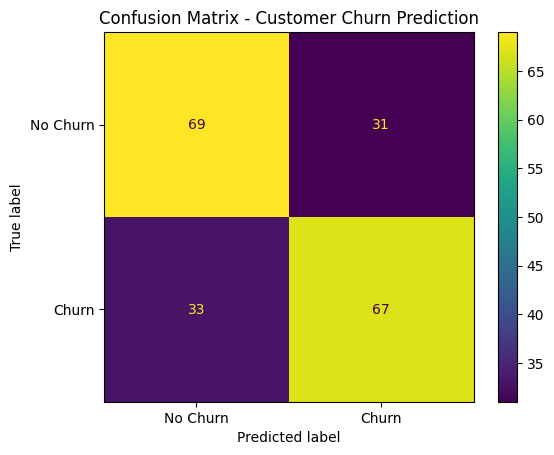

In [ ]:
 from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Customer Churn Prediction")
plt.show()

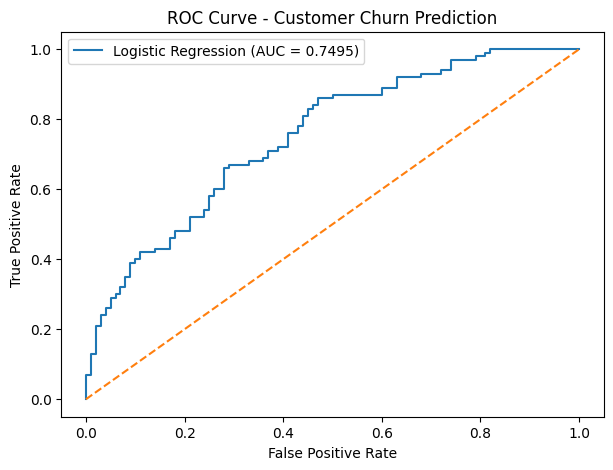

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")
plt.legend()
plt.show()

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("Feature Coefficients:")
display(coefficients)

Feature Coefficients:


,Feature,Coefficient,Absolute_Coefficient
1,monthly_charges,0.646803,0.646803
5,contract_months,0.536243,0.536243
3,avg_session_minutes,0.508222,0.508222
2,support_tickets,-0.447767,0.447767
4,late_payments,-0.428239,0.428239
0,tenure_months,-0.351499,0.351499


In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients

,Feature,Coefficient
0,tenure_months,-0.351499
1,monthly_charges,0.646803
2,support_tickets,-0.447767
3,avg_session_minutes,0.508222
4,late_payments,-0.428239
5,contract_months,0.536243


### Limitations and Improvements

The Logistic Regression model assumes a linear relationship between the input features and the log-odds of the target. The model performance may also vary when applied to new customer data.

To improve the model, additional relevant customer features, larger datasets, and alternative classification algorithms could be considered.

### Conclusion

The Logistic Regression model was used to predict customer churn risk based on the available customer features. The model achieved reasonable performance across the evaluation metrics, with an ROC AUC of 0.7495. The results show that Logistic Regression can provide a useful baseline for identifying customers who are more likely to churn.